# NB-03: 馬場差（Δtrack）算出

**目的**: 当日の馬場差（Δtrack）を「開催日×開催場×コース(芝/ダ)」単位で算出する。

$$
\Delta_{\text{track}} = \text{mean}(\text{time\_after\_pace}) - \text{mean}(\text{par\_time})
$$

- 正値 → 遅い馬場（タイムが掛かる）
- 負値 → 速い馬場（タイムが出やすい）

## セクション1: セットアップ

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

warnings.filterwarnings('ignore')

# 日本語フォント設定
import matplotlib
import matplotlib.font_manager as fm

jp_fonts = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ['Gothic', 'Meiryo', 'Noto', 'IPAex', 'Yu', 'MS PGothic'])]
if jp_fonts:
    matplotlib.rcParams['font.family'] = jp_fonts[0]
    print(f'日本語フォント設定: {jp_fonts[0]}')
else:
    matplotlib.rcParams['font.family'] = 'DejaVu Sans'
    print('日本語フォントが見つかりません。DejaVu Sans を使用します。')

matplotlib.rcParams['axes.unicode_minus'] = False
print('セットアップ完了')

日本語フォント設定: URW Gothic
セットアップ完了


## セクション2: データロード

In [2]:
# パス定義
NB01_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb01')
NB02_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb02')
OUTPUT_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb03')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'出力先: {OUTPUT_DIR}')

# データロード
print('\n[1/3] megu_dataset を読み込み中...')
df = pd.read_parquet(NB01_DIR / 'megu_dataset.parquet')
print(f'  shape: {df.shape}')

print('[2/3] coeff_pace を読み込み中...')
coeff_pace = pd.read_parquet(NB02_DIR / 'coeff_pace.parquet')
print(f'  shape: {coeff_pace.shape}')
print(f'  列: {coeff_pace.columns.tolist()}')

print('[3/3] par_time_class を読み込み中...')
par_time_class = pd.read_parquet(NB02_DIR / 'par_time_class.parquet')
print(f'  shape: {par_time_class.shape}')
print(f'  列: {par_time_class.columns.tolist()}')

print('\nデータロード完了')

出力先: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb03

[1/3] megu_dataset を読み込み中...


  shape: (302357, 39)
[2/3] coeff_pace を読み込み中...
  shape: (126, 6)
  列: ['venue', 'surface', 'distance', 'coeff_pace', 'n_fit', 'source']
[3/3] par_time_class を読み込み中...
  shape: (861, 9)
  列: ['venue', 'surface', 'distance', 'class_rank', 'par_time_sec', 'alpha', 'beta', 'n_fit', 'source']

データロード完了


In [3]:
# coeff_pace を venue×surface×distance でマージ
print('coeff_pace を megu_dataset にマージ中...')

# coeff_pace の列名確認・必要列の選択
coeff_cols = ['venue', 'surface', 'distance', 'coeff_pace']
available_coeff_cols = [c for c in coeff_cols if c in coeff_pace.columns]
print(f'  使用列: {available_coeff_cols}')

coeff_pace_slim = coeff_pace[available_coeff_cols].drop_duplicates()

# データ型統一
for col in ['venue', 'surface']:
    if col in df.columns:
        df[col] = df[col].astype(str)
    if col in coeff_pace_slim.columns:
        coeff_pace_slim[col] = coeff_pace_slim[col].astype(str)

df['distance'] = pd.to_numeric(df['distance'], errors='coerce')
coeff_pace_slim['distance'] = pd.to_numeric(coeff_pace_slim['distance'], errors='coerce')

df = df.merge(coeff_pace_slim, on=['venue', 'surface', 'distance'], how='left')

matched = df['coeff_pace'].notna().sum()
total = len(df)
print(f'  coeff_pace マッチ率: {matched}/{total} ({matched/total*100:.1f}%)')
print('マージ完了')

coeff_pace を megu_dataset にマージ中...
  使用列: ['venue', 'surface', 'distance', 'coeff_pace']


  coeff_pace マッチ率: 302357/302357 (100.0%)
マージ完了


## セクション3: クラスランク付与

In [4]:
from src.pipeline.megu_index.track_speed import assign_class_rank

print('クラスランクを付与中（NB-01/NB-02 共通定義を使用）...')

# NB-01 track_speed.py / NB-02 fit_par_time_class.py と同一の定義を使う。
# 独自の CLASS_RANK 辞書を定義すると NB-02 の par_time_class とキーがずれて
# マージ時に G2/G1 レースへ誤った par_time が当たるため、必ず共通関数を使用すること。
df['class_rank'] = df.apply(
    lambda r: assign_class_rank(r['grade'], r['race_class']), axis=1
)
df['class_rank'] = df['class_rank'].fillna(2).astype(int)  # デフォルト: 1勝クラス相当

print('クラスランク分布:')
print(df['class_rank'].value_counts().sort_index())
print('クラスランク付与完了')


クラスランクを付与中（NB-01/NB-02 共通定義を使用）...


クラスランク分布:
class_rank
1    112181
2    102243
3     40766
4     19909
5     14747
6      6469
7      3448
8      2594
Name: count, dtype: int64
クラスランク付与完了


## セクション4: par_time の対応付け

In [5]:
print('par_time_class を各馬にマージ中...')

# par_time_class の型統一
par_slim = par_time_class[['venue', 'surface', 'distance', 'class_rank', 'par_time_sec']].copy()
par_slim['venue'] = par_slim['venue'].astype(str)
par_slim['surface'] = par_slim['surface'].astype(str)
par_slim['distance'] = pd.to_numeric(par_slim['distance'], errors='coerce')
par_slim['class_rank'] = pd.to_numeric(par_slim['class_rank'], errors='coerce').astype('Int64')

df['class_rank_key'] = df['class_rank'].astype('Int64')

df = df.merge(
    par_slim,
    left_on=['venue', 'surface', 'distance', 'class_rank_key'],
    right_on=['venue', 'surface', 'distance', 'class_rank'],
    how='left',
    suffixes=('', '_par')
)

matched_par = df['par_time_sec'].notna().sum()
total = len(df)
print(f'  par_time マッチ率: {matched_par}/{total} ({matched_par/total*100:.1f}%)')

# par_time 未定義の馬はΔtrack算出から除外
df_valid = df[df['par_time_sec'].notna()].copy()
print(f'  Δtrack算出対象レコード数: {len(df_valid)}')
print('par_time マージ完了')

par_time_class を各馬にマージ中...


  par_time マッチ率: 299689/302357 (99.1%)


  Δtrack算出対象レコード数: 299689
par_time マージ完了


## セクション5: front_split_dev の計算

In [6]:
print('front_split_dev を計算中...')

# megu_dataset.parquet には NB-01 §6 で算出した par_front_split_sec が含まれている。
# front_split_dev = 実測前半スプリット − 基準前半スプリット（連続 OLS モデル値）
# この偏差に coeff_pace を乗じることでペース補正量 Δpace を得る。
df_valid['front_split_dev'] = (
    df_valid['front_split_sec'] - df_valid['par_front_split_sec']
)

# 欠損（front_split_sec 未取得レース等）は 0 補完 → ペース補正なし扱い
df_valid['front_split_dev'] = df_valid['front_split_dev'].fillna(0.0)

cov = df_valid['front_split_sec'].notna().mean()
print(f'  front_split_sec カバレッジ: {cov:.1%}')
print(f'  front_split_dev 非null: {(df_valid["front_split_dev"] != 0.0).sum():,} 件')
print(f'  front_split_dev 統計:')
print(df_valid['front_split_dev'].describe().round(3))
print('front_split_dev 計算完了')


front_split_dev を計算中...
  front_split_sec カバレッジ: 97.7%
  front_split_dev 非null: 292,757 件
  front_split_dev 統計:
count    299689.000
mean         -0.041
std           0.826
min          -6.352
25%          -0.514
50%          -0.025
75%           0.442
max          10.988
Name: front_split_dev, dtype: float64
front_split_dev 計算完了


## セクション6: Δpace の適用

In [7]:
print('Δpace を adjusted_time_sec に適用中...')

# coeff_pace が欠損の場合は 0 とする
df_valid['coeff_pace_fill'] = df_valid['coeff_pace'].fillna(0.0)

# Δpace = coeff_pace × front_split_dev
df_valid['delta_pace_sec'] = df_valid['coeff_pace_fill'] * df_valid['front_split_dev']

# ペース補正後タイム
df_valid['time_after_pace'] = df_valid['adjusted_time_sec'] - df_valid['delta_pace_sec']

print(f'  delta_pace_sec 統計:')
print(df_valid['delta_pace_sec'].describe().round(3))
print(f'  time_after_pace 統計:')
print(df_valid['time_after_pace'].describe().round(3))
print('Δpace 適用完了')

Δpace を adjusted_time_sec に適用中...
  delta_pace_sec 統計:


count    299689.000
mean         -0.051
std           0.648
min          -4.502
25%          -0.371
50%          -0.014
75%           0.273
max           7.693
Name: delta_pace_sec, dtype: float64
  time_after_pace 統計:
count    299689.000
mean        101.783
std          27.822
min          53.508
25%          80.767
50%         100.283
75%         116.821
max         304.835
Name: time_after_pace, dtype: float64
Δpace 適用完了


## セクション7: Δtrack の算出

### 7-1. 対象レースフィルタ（未勝利〜G3、G1除外）

In [8]:
# 対象: G1 レースを除外（class_rank <= 7 = 未勝利〜G2 を含め G1 のみ除外）
# NB-01 定義: G3=6, G2=7, G1=8
# 旧コードの "class_rank <= 6" は旧 CLASS_RANK（G2=6）に合わせたもの。
# assign_class_rank に統一した現在は G1 のみ除外するために <= 7 に変更。
print('対象レースをフィルタ中（G1 のみ除外: class_rank <= 7）...')

track_target = df_valid[df_valid['class_rank'] <= 7].copy()

print(f'  フィルタ前: {len(df_valid):,} 行')
print(f'  フィルタ後: {len(track_target):,} 行')
print(f'  除外（G1）: {len(df_valid) - len(track_target):,} 行')
print('フィルタ完了')


対象レースをフィルタ中（G1 のみ除外: class_rank <= 7）...


  フィルタ前: 299,689 行
  フィルタ後: 299,689 行
  除外（G1）: 0 行
フィルタ完了


### 7-2. 日別×会場×コース単位で集計

In [9]:
print('日別×会場×コース単位で Δtrack を集計中...')

# date 列の型確認・変換
if 'date' in track_target.columns:
    track_target['date'] = track_target['date'].astype(str).str[:10]  # YYYY-MM-DD

group_cols = ['date', 'venue', 'surface']

agg_dict = {
    'time_after_pace': 'mean',
    'par_time_sec': 'mean',
}

# race_id でユニーク数カウントするための準備
grouped = track_target.groupby(group_cols)

delta_track = grouped.agg(
    mean_time_after_pace=('time_after_pace', 'mean'),
    mean_par_time=('par_time_sec', 'mean'),
    n_races=('race_id', 'nunique')
).reset_index()

# Δtrack 算出
delta_track['delta_track_sec'] = delta_track['mean_time_after_pace'] - delta_track['mean_par_time']

print(f'  集計結果: {len(delta_track):,} 行（日付×会場×コース）')
print(delta_track[['date', 'venue', 'surface', 'delta_track_sec', 'n_races']].head(10))
print('集計完了')

日別×会場×コース単位で Δtrack を集計中...


  集計結果: 3,721 行（日付×会場×コース）
         date venue surface  delta_track_sec  n_races
0  2020-01-05    中山     ダート         3.547458        7
1  2020-01-05    中山       芝         0.458140        5
2  2020-01-05    京都     ダート         1.611091        7
3  2020-01-05    京都       芝         3.946179        5
4  2020-01-06    中山     ダート         3.223950        8
5  2020-01-06    中山       芝         1.614105        4
6  2020-01-06    京都     ダート         1.951404        7
7  2020-01-06    京都       芝         3.860213        5
8  2020-01-11    中山     ダート         2.573515        8
9  2020-01-11    中山       芝         1.052773        4
集計完了


### 7-3. Sparse 対策

In [10]:
print('Sparse対策: n_races < 3 の場合は Δtrack = 0, is_fallback = True に設定...')

delta_track['is_fallback'] = delta_track['n_races'] < 3
delta_track.loc[delta_track['is_fallback'], 'delta_track_sec'] = 0.0

n_fallback = delta_track['is_fallback'].sum()
n_total = len(delta_track)
print(f'  is_fallback 件数: {n_fallback}/{n_total} ({n_fallback/n_total*100:.1f}%)')

# 最終スキーマに整形
delta_track = delta_track[['date', 'venue', 'surface', 'delta_track_sec', 'n_races', 'is_fallback']].copy()
delta_track['delta_track_sec'] = delta_track['delta_track_sec'].astype(float).round(4)
delta_track['n_races'] = delta_track['n_races'].astype(int)
delta_track['is_fallback'] = delta_track['is_fallback'].astype(bool)

print('Sparse対策完了')

Sparse対策: n_races < 3 の場合は Δtrack = 0, is_fallback = True に設定...
  is_fallback 件数: 19/3721 (0.5%)
Sparse対策完了


### 7-4. 符号の確認

In [11]:
print('符号確認: delta_track_sec の分布')
print(f'  全体統計:')
print(delta_track['delta_track_sec'].describe().round(3))
print()

# 速い馬場（負値）と遅い馬場（正値）の割合
n_fast = (delta_track['delta_track_sec'] < 0).sum()
n_slow = (delta_track['delta_track_sec'] > 0).sum()
n_neut = (delta_track['delta_track_sec'] == 0).sum()
n_total = len(delta_track)
print(f'  速い馬場（δ<0）: {n_fast:,}件 ({n_fast/n_total*100:.1f}%)')
print(f'  標準（δ=0）  : {n_neut:,}件 ({n_neut/n_total*100:.1f}%)')
print(f'  遅い馬場（δ>0）: {n_slow:,}件 ({n_slow/n_total*100:.1f}%)')

# 年別の分布
if 'date' in delta_track.columns:
    delta_track['year'] = delta_track['date'].str[:4]
    print('\n年別の delta_track_sec 平均:')
    print(delta_track.groupby('year')['delta_track_sec'].mean().round(3))

# 会場別の分布
print('\n会場別の delta_track_sec 平均（上位10会場）:')
print(delta_track.groupby('venue')['delta_track_sec'].mean().sort_values().head(10).round(3))
print('符号確認完了')

符号確認: delta_track_sec の分布
  全体統計:
count    3721.000
mean        1.497
std         1.167
min        -2.410
25%         0.725
50%         1.485
75%         2.185
max         9.156
Name: delta_track_sec, dtype: float64

  速い馬場（δ<0）: 315件 (8.5%)
  標準（δ=0）  : 19件 (0.5%)
  遅い馬場（δ>0）: 3,387件 (91.0%)

年別の delta_track_sec 平均:
year
2020    1.906
2021    1.627
2022    1.581
2023    1.557
2024    1.373
2025    1.260
2026    0.794
Name: delta_track_sec, dtype: float64

会場別の delta_track_sec 平均（上位10会場）:
venue
函館    1.175
札幌    1.366
阪神    1.412
京都    1.435
東京    1.443
福島    1.487
中京    1.494
小倉    1.573
中山    1.658
新潟    1.678
Name: delta_track_sec, dtype: float64
符号確認完了


## セクション8: 検証・可視化

可視化を作成中...


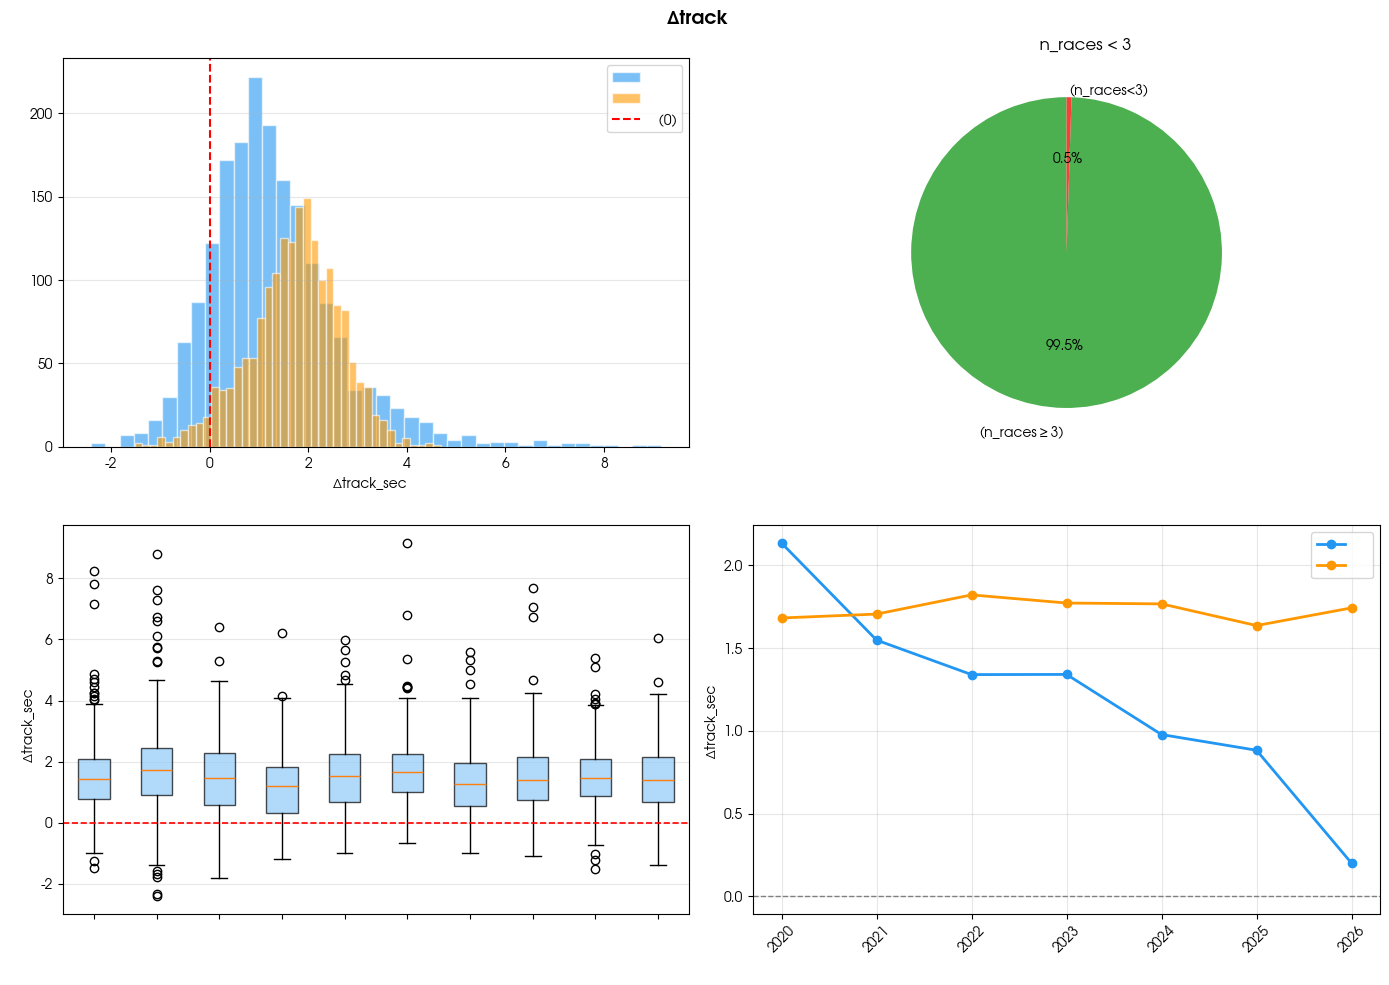

可視化完了


In [12]:
print('可視化を作成中...')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('馬場差（Δtrack）分析', fontsize=14, fontweight='bold')

# --- (1) 芝・ダート別のヒストグラム ---
ax1 = axes[0, 0]
for surface, color in [('芝', '#2196F3'), ('ダート', '#FF9800'), ('ダ', '#FF9800')]:
    sub = delta_track[delta_track['surface'] == surface]
    if len(sub) == 0:
        continue
    sub_valid = sub[~sub['is_fallback']]
    if len(sub_valid) > 0:
        label = surface if surface != 'ダ' else 'ダート'
        ax1.hist(sub_valid['delta_track_sec'], bins=40, alpha=0.6, color=color, label=label, edgecolor='white')

ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='基準(0)')
ax1.set_xlabel('Δtrack_sec（秒）')
ax1.set_ylabel('件数')
ax1.set_title('馬場差の分布（芝・ダート別）')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# --- (2) is_fallback の割合 ---
ax2 = axes[0, 1]
fallback_counts = delta_track['is_fallback'].value_counts()
labels_fb = ['通常算出\n(n_races≥3)', 'フォールバック\n(n_races<3)']
colors_fb = ['#4CAF50', '#F44336']
ax2.pie(
    [fallback_counts.get(False, 0), fallback_counts.get(True, 0)],
    labels=labels_fb,
    colors=colors_fb,
    autopct='%1.1f%%',
    startangle=90
)
ax2.set_title('フォールバック率（n_races < 3）')

# --- (3) 会場別の箱ひげ図 ---
ax3 = axes[1, 0]
venue_data = delta_track[~delta_track['is_fallback']].groupby('venue')['delta_track_sec'].apply(list)
venue_names = venue_data.index.tolist()
venue_vals = venue_data.values.tolist()
if venue_vals:
    bp = ax3.boxplot(venue_vals, labels=venue_names, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#90CAF9')
        patch.set_alpha(0.7)
    ax3.axhline(0, color='red', linestyle='--', linewidth=1.2)
    ax3.set_xlabel('開催場')
    ax3.set_ylabel('Δtrack_sec（秒）')
    ax3.set_title('会場別馬場差の分布')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(axis='y', alpha=0.3)

# --- (4) 年別の平均馬場差（折れ線）---
ax4 = axes[1, 1]
if 'year' in delta_track.columns:
    for surface, color in [('芝', '#2196F3'), ('ダート', '#FF9800'), ('ダ', '#FF9800')]:
        sub = delta_track[(delta_track['surface'] == surface) & (~delta_track['is_fallback'])]
        if len(sub) == 0:
            continue
        yearly = sub.groupby('year')['delta_track_sec'].mean()
        label = surface if surface != 'ダ' else 'ダート'
        ax4.plot(yearly.index, yearly.values, marker='o', color=color, label=label, linewidth=2)
    ax4.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax4.set_xlabel('年')
    ax4.set_ylabel('平均Δtrack_sec（秒）')
    ax4.set_title('年別の平均馬場差推移')
    ax4.legend()
    ax4.grid(alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)
else:
    ax4.text(0.5, 0.5, 'year列がありません', ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'delta_track_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print('可視化完了')

季節性チェック（月別）...


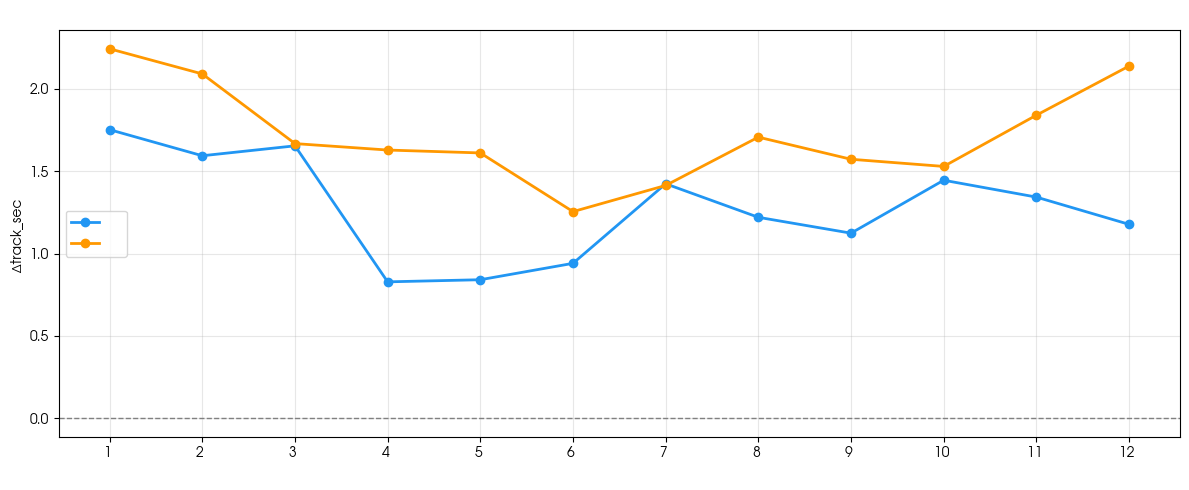

季節性チェック完了


In [13]:
# 追加: 季節性チェック（月別の馬場差）
print('季節性チェック（月別）...')

if 'date' in delta_track.columns:
    delta_track['month'] = delta_track['date'].str[5:7].astype(int)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    for surface, color in [('芝', '#2196F3'), ('ダート', '#FF9800'), ('ダ', '#FF9800')]:
        sub = delta_track[(delta_track['surface'] == surface) & (~delta_track['is_fallback'])]
        if len(sub) == 0:
            continue
        monthly = sub.groupby('month')['delta_track_sec'].mean()
        label = surface if surface != 'ダ' else 'ダート'
        ax.plot(monthly.index, monthly.values, marker='o', color=color, label=label, linewidth=2)
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('月')
    ax.set_ylabel('平均Δtrack_sec（秒）')
    ax.set_title('月別の平均馬場差（季節性）')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([f'{m}月' for m in range(1, 13)])
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'delta_track_seasonal.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('季節性チェック完了')
else:
    print('date列がないため季節性チェックをスキップします')

## セクション9: 保存

In [14]:
print('delta_track を保存中...')

# 最終列確認
output_cols = ['date', 'venue', 'surface', 'delta_track_sec', 'n_races', 'is_fallback']
delta_track_out = delta_track[output_cols].copy()

# 型の最終確認
delta_track_out['date'] = delta_track_out['date'].astype(str)
delta_track_out['venue'] = delta_track_out['venue'].astype(str)
delta_track_out['surface'] = delta_track_out['surface'].astype(str)
delta_track_out['delta_track_sec'] = delta_track_out['delta_track_sec'].astype(float)
delta_track_out['n_races'] = delta_track_out['n_races'].astype(int)
delta_track_out['is_fallback'] = delta_track_out['is_fallback'].astype(bool)

# 保存
out_path = OUTPUT_DIR / 'delta_track.parquet'
delta_track_out.to_parquet(out_path, index=False)
print(f'  保存完了: {out_path}')
print(f'  shape: {delta_track_out.shape}')
print()
print('--- head(10) ---')
print(delta_track_out.head(10).to_string())
print()
print('--- dtypes ---')
print(delta_track_out.dtypes)
print()
print('--- 統計サマリー ---')
print(delta_track_out.describe(include='all').round(3))
print('\n=== NB-03 完了 ===')

delta_track を保存中...
  保存完了: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb03/delta_track.parquet
  shape: (3721, 6)

--- head(10) ---
         date venue surface  delta_track_sec  n_races  is_fallback
0  2020-01-05    中山     ダート           3.5475        7        False
1  2020-01-05    中山       芝           0.4581        5        False
2  2020-01-05    京都     ダート           1.6111        7        False
3  2020-01-05    京都       芝           3.9462        5        False
4  2020-01-06    中山     ダート           3.2239        8        False
5  2020-01-06    中山       芝           1.6141        4        False
6  2020-01-06    京都     ダート           1.9514        7        False
7  2020-01-06    京都       芝           3.8602        5        False
8  2020-01-11    中山     ダート           2.5735        8        False
9  2020-01-11    中山       芝           1.0528        4        False

--- dtypes ---
date                object
venue               object
surface             object
delta_track_sec    f